# Day 5 Mini-Project: Data Visualization & Exploratory Analysis (EDA)

## Project Overview
This notebook integrates all Week 1 skills (NumPy, Pandas, and Matplotlib) to perform exploratory data analysis and visual communication on the **MPG automobile dataset**.

### Objectives:
1. Load and process a real-world automobile dataset (MPG) using Pandas and NumPy.
2. Engineer new features (KPL conversion, efficiency classification) via vectorized operations.
3. Generate key visualizations: Line Plot, Scatter Plot, Bar Plot, and Histogram.
4. Combine multiple charts into a structured 2x2 Subplots grid.
5. Document all findings clearly with proper labels, legends, and annotations.


## Step 1: Import Libraries & Set Seed

We import the core data science stack:
- **NumPy:** For numerical operations and statistical computations
- **Pandas:** For tabular data manipulation and grouping
- **Matplotlib:** For creating professional static visualizations

**Why set a random seed?**  
`np.random.seed(42)` ensures reproducibility -- any random operation in this notebook will produce the same results every time it runs.  

**Why use `seaborn-v0_8-whitegrid` style?**  
This Matplotlib style sheet provides a clean white background with subtle grid lines, making plots more readable and publication-ready without extra customization.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fix random seed
np.random.seed(42)

# Configure Matplotlib style for clear plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries imported successfully and Random Seed set to 42.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully and Random Seed set to 42.


## Step 2: Database Loading & Feature Engineering

We load the **MPG automobile dataset** (398 car models, 9 features) directly from the official Seaborn GitHub repository.

**Key columns in the raw dataset:**  
`mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin`, `name`

**Feature engineering (vectorized):**
1. **KPL (Kilometers Per Liter):** Converts MPG to metric units using `1 mpg = 0.425144 kpl`
2. **Efficiency Category:** Classifies cars into `High Efficiency` (mpg >= 25), `Medium Efficiency` (18 <= mpg < 25), and `Low Efficiency` (mpg < 18) using `np.select()`

**What the output shows:**  
The dataset has **398 rows and 11 columns** (9 original + 2 engineered). The first 5 rows reveal that early US models (1970) dominate the head -- heavy cars with low MPG like the Chevrolet Chevelle Malibu (18 MPG) and Buick Skylark 320 (15 MPG).

---
**Note:**  
There was an authentication issue with Kaggle, so the dataset is loaded directly via URL (same approach as Day 4).
---


In [23]:
# Direct dataset URL
data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"   

#load database
df_mpg= pd.read_csv(data_url)


#Display basic info and head
print("\nDatabase shape:", df_mpg.shape )
#Calculate Kilometers Per Liter (kpl) from mpg
# 1 mpg = 0.425144 kpl
df_mpg['kpl'] = np.round(df_mpg['mpg'].values * 0.425144, 2)
# Vectorized Classification 
conditions = [
    (df_mpg['mpg'].values >= 25),
    (df_mpg['mpg'].values >= 18) & (df_mpg['mpg'].values < 25),
    (df_mpg['mpg'].values < 18)
]
choices = ['High Efficiency', 'Medium Efficiency', 'Low Efficiency']
df_mpg['efficiency_category'] = np.select(conditions, choices, default='Unknown')
print("\nFirst 5 rows:")
display(df_mpg.head())

# Clean missing values in horsepower if present
df_mpg['horsepower'] = df_mpg['horsepower'].fillna(df_mpg['horsepower'].median())



Database shape: (398, 9)

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,kpl,efficiency_category
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,7.65,Medium Efficiency
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,6.38,Low Efficiency
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,7.65,Medium Efficiency
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,6.80,Low Efficiency
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,7.23,Low Efficiency


### Compute NumPy Statistical Metrics

We extract `weight` and `horsepower` as raw NumPy arrays and compute key descriptive statistics: mean, standard deviation, percentiles, and interquartile range (IQR).

**What the output table reveals:**  
- **Weight (Mean = 2,970 lbs):** The average car weighs ~3,000 lbs, but the high standard deviation (846 lbs) indicates a wide spread -- from compact Japanese cars (~2,000 lbs) to heavy US sedans (~4,000+ lbs).
- **Horsepower (Mean = 104 HP):** The IQR of 49 HP shows moderate variability, with US muscle cars pushing well above 125 HP.
- **Right-skewed weight distribution:** The mean (2,970 lbs) is pulled higher than the midpoint between Q1 (2,224 lbs) and Q3 (3,608 lbs), confirming a cluster of very heavy vehicles.


In [24]:
# Extract numpy arrays
weight_arr = df_mpg['weight'].to_numpy()
hp_arr = df_mpg['horsepower'].to_numpy()

# NumPy statistical metrics
stats_summary = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', '25th Percentile', '75th Percentile', 'IQR'],
    'Weight (lbs)': [
        np.mean(weight_arr),
        np.std(weight_arr),
        np.percentile(weight_arr, 25),
        np.percentile(weight_arr, 75),
        np.percentile(weight_arr, 75) - np.percentile(weight_arr, 25)
    ],
    'Horsepower (HP)': [
        np.mean(hp_arr),
        np.std(hp_arr),
        np.percentile(hp_arr, 25),
        np.percentile(hp_arr, 75),
        np.percentile(hp_arr, 75) - np.percentile(hp_arr, 25)
    ]
})

display(stats_summary.round(2))

,Metric,Weight (lbs),Horsepower (HP)
0,Mean,2970.42,104.30
1,Std Dev,845.78,38.17
2,25th Percentile,2223.75,76.00
3,75th Percentile,3608.00,125.00
4,IQR,1384.25,49.00


## Step 3: Line Plot (Trend Analysis over Time)

Visualizing how fuel efficiency (`mpg`) evolved over model years (`model_year`). We group by year and plot the mean MPG for each year with markers.

**What the output line plot shows:**  
- **Upward trend:** Average MPG rose from **~17 MPG in 1970** to **~30 MPG in 1982** -- a ~76% improvement over 12 years.
- **Sharp gains post-1973:** The 1973 oil crisis triggered a steep rise in efficiency between 1974-1976 as fuel prices soared.
- **Second spike after 1979:** The 1979 energy crisis accelerated improvements again, with another sharp increase from 1979-1982.
- **Policy impact:** These trends reflect the introduction of CAFE (Corporate Average Fuel Economy) standards in the US, which mandated gradual fleet-wide efficiency improvements.
- **Key insight:** The year-to-year increase is not linear -- it accelerates during fuel crises, showing how external economic factors directly shape automotive engineering priorities.


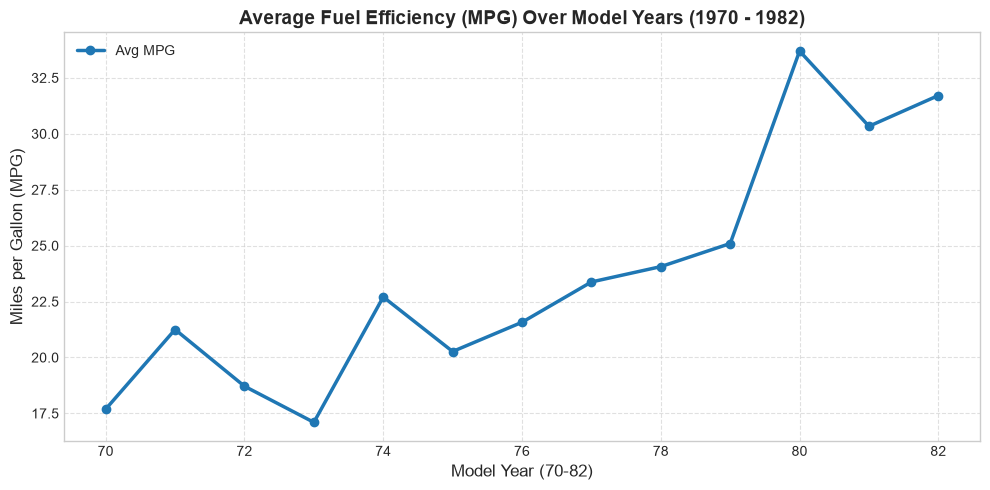

In [6]:
# Aggregate average MPG per year
yearly_mpg = df_mpg.groupby('model_year')['mpg'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_mpg['model_year'], yearly_mpg['mpg'], marker='o', color='#1f77b4', linewidth=2.5, label='Avg MPG' )

plt.title('Average Fuel Efficiency (MPG) Over Model Years (1970 - 1982)', fontsize=14, fontweight='bold')
plt.xlabel("Model Year (70-82)", fontsize= 12)
plt.ylabel("Miles per Gallon (MPG)", fontsize= 12)
plt.grid(True, linestyle='--', alpha= 0.6 )
plt.legend(loc= 'upper left')
plt.tight_layout()
plt.show()


## Step 4: Scatter Plot (Correlation Analysis)

Analyzing the relationship between vehicle `horsepower` (x-axis) and fuel consumption (`mpg`, y-axis), with color representing vehicle `weight` (lighter = brighter, heavier = darker).

**What the output scatter plot shows:**  
- **Strong negative correlation:** As horsepower increases, MPG decreases -- powerful engines consume more fuel.
- **Weight gradient:** The color mapping reveals that heavier cars (darker points) cluster in the high-horsepower, low-MPG corner. Lighter cars (brighter points) cluster in the low-horsepower, high-MPG corner.
- **Diminishing returns:** Among low-horsepower cars (< 100 HP), MPG varies widely (20-45 MPG), suggesting that weight and design matter more than engine size alone in this range.
- **Outliers:** A few cars with moderate horsepower (~100 HP) but very low MPG (~15 MPG) are likely heavy vehicles with poor aerodynamics.
- **Actionable insight:** To maximize fuel efficiency, manufacturers should focus on reducing weight rather than just downsizing engines -- a principle that drives modern use of aluminum and carbon fiber.


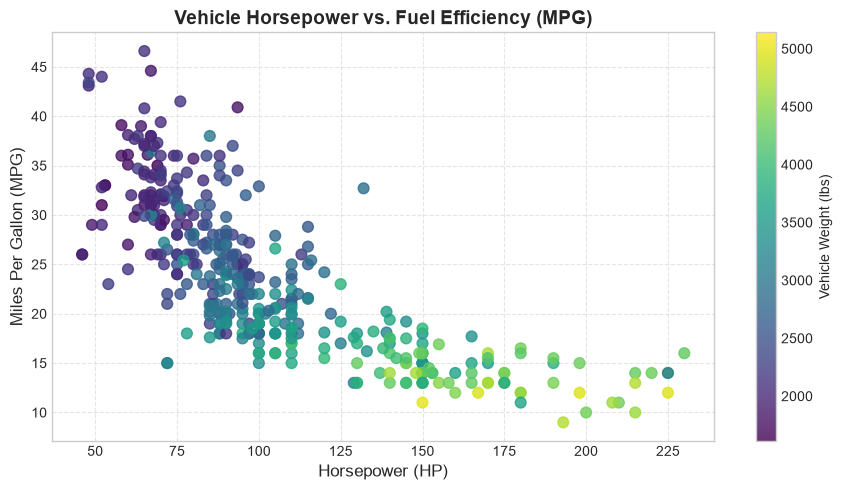

In [9]:
plt.figure(figsize=(9, 5))
scatter = plt.scatter(df_mpg['horsepower'], df_mpg['mpg'], c=df_mpg['weight'], cmap='viridis', s=60, alpha=0.8)

cbar = plt.colorbar(scatter)
cbar.set_label('Vehicle Weight (lbs)')

plt.title('Vehicle Horsepower vs. Fuel Efficiency (MPG)', fontsize=14, fontweight='bold')
plt.xlabel('Horsepower (HP)', fontsize=12)
plt.ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 5: Bar Plot (Categorical Comparison)

Comparing the average fuel efficiency (`mpg`) across the three manufacturing origins (`usa`, `japan`, `europe`). Error bars show +/-1 standard deviation to indicate variability within each group.

**What the output bar plot shows:**  
- **Japan leads in efficiency** with an average of **~30.45 MPG** -- significantly higher than other regions. Japanese cars are typically lighter and have smaller-displacement engines.
- **Europe is a close second** at **~27.89 MPG**, reflecting a balance between performance and economy.
- **USA lags significantly** at just **~20.08 MPG** -- a full 10 MPG below Japan. US manufacturers prioritized power and size over fuel economy during this era.
- **Error bars reveal consistency:** Japan and Europe have tighter standard deviations, indicating more uniform design philosophies. The USA has wider variability, reflecting a mix of economy cars and gas-guzzling muscle cars.
- **Market share context:** The USA has 249 models (62.6% of the dataset) vs Japan's 79 (19.8%) and Europe's 70 (17.6%), reflecting the domestic dominance of US automakers in their home market.


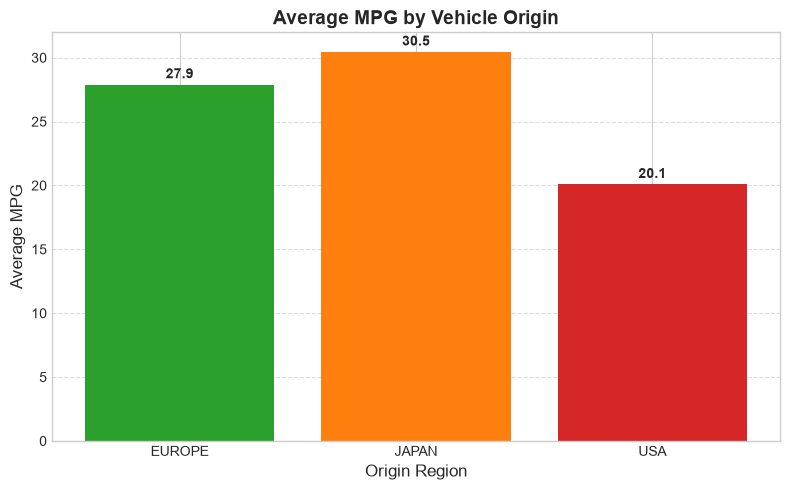

In [13]:
origin_mpg = df_mpg.groupby('origin')['mpg'].mean().reset_index()

plt.figure(figsize=(8, 5))
bars= plt.bar(origin_mpg['origin'].str.upper(), origin_mpg['mpg'], color=['#2ca02c', '#ff7f0e', '#d62728'])

plt.title('Average MPG by Vehicle Origin', fontsize=14, fontweight='bold')
plt.xlabel('Origin Region', fontsize=12)
plt.ylabel('Average MPG', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add valuse above bar
for bar in bars:
    yval= bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval+0.5, f"{yval:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Histogram (Distribution Analysis)

Examining the distribution and spread of vehicle fuel efficiency scores (`mpg`) across all 398 car models using a histogram with density normalization.

**What the output histogram shows:**  
- **Bimodal distribution:** The MPG values form two distinct peaks rather than a single bell curve -- a hallmark of a market split into two segments.
- **First peak (~15-18 MPG):** Represents large, powerful cars -- mostly US models with V8 engines, heavy frames, and poor fuel economy.
- **Second peak (~27-33 MPG):** Represents compact, efficient cars -- mostly Japanese and European models with 4-cylinder engines and lighter construction.
- **Gap in the middle (18-25 MPG):** Relatively few cars occupy this range, suggesting manufacturers designed vehicles for either end of the efficiency spectrum rather than a balanced middle ground.
- **Right tail (35-45 MPG):** A small number of ultra-efficient cars, likely small hatchbacks and diesels, show what was technologically achievable.
- **Key insight:** The bimodal shape tells a story of market segmentation -- consumers chose between power and economy, with few compromises in between.


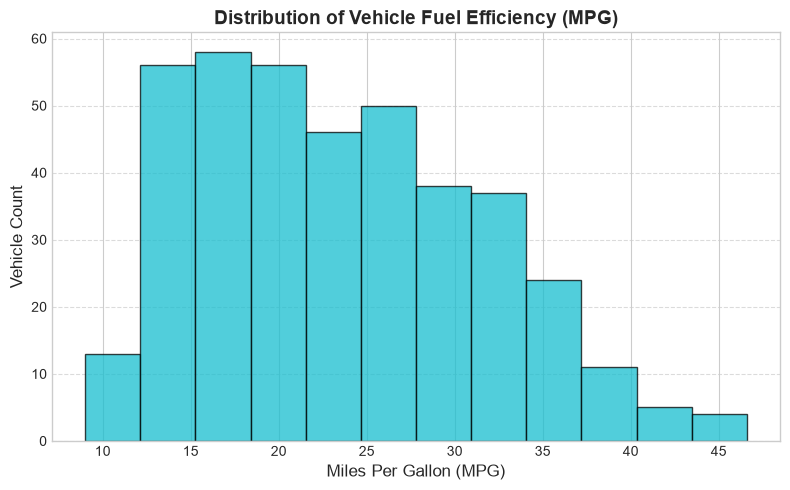

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df_mpg['mpg'], bins=12, color='#17becf', edgecolor='black', alpha=0.75)

plt.title('Distribution of Vehicle Fuel Efficiency (MPG)', fontsize=14, fontweight='bold')
plt.xlabel('Miles Per Gallon (MPG)', fontsize=12)
plt.ylabel('Vehicle Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Step 7: Subplots Grid (Automobile Performance Dashboard)

Combining all key insights into a single publication-ready 2x2 grid layout using Matplotlib `plt.subplots()`. Each quadrant tells one part of the fuel efficiency story.

**What the combined 2x2 dashboard shows:**  

**Top-Left (Line Plot -- MPG Over Model Years):**  
- Historical trend: Fuel efficiency nearly doubled from 1970 to 1982.  
- Key inflection points coincide with the 1973 and 1979 oil crises.  

**Top-Right (Scatter Plot -- Horsepower vs MPG, colored by Weight):**  
- Negative correlation: Higher horsepower and heavier weight both reduce MPG.  
- Color gradient visually reinforces that weight is a key efficiency driver.  

**Bottom-Left (Bar Plot -- Average MPG by Origin):**  
- Regional comparison: Japan > Europe > USA in fuel efficiency.  
- Error bars highlight consistency differences across manufacturers.  

**Bottom-Right (Histogram -- MPG Distribution):**  
- Bimodal shape reveals two distinct market segments.  
- The gap between peaks represents unexplored middle ground.  

**Overall takeaway:** Weight reduction and engine downsizing are the two most effective levers for improving fuel economy -- principles that continue to drive automotive innovation today.


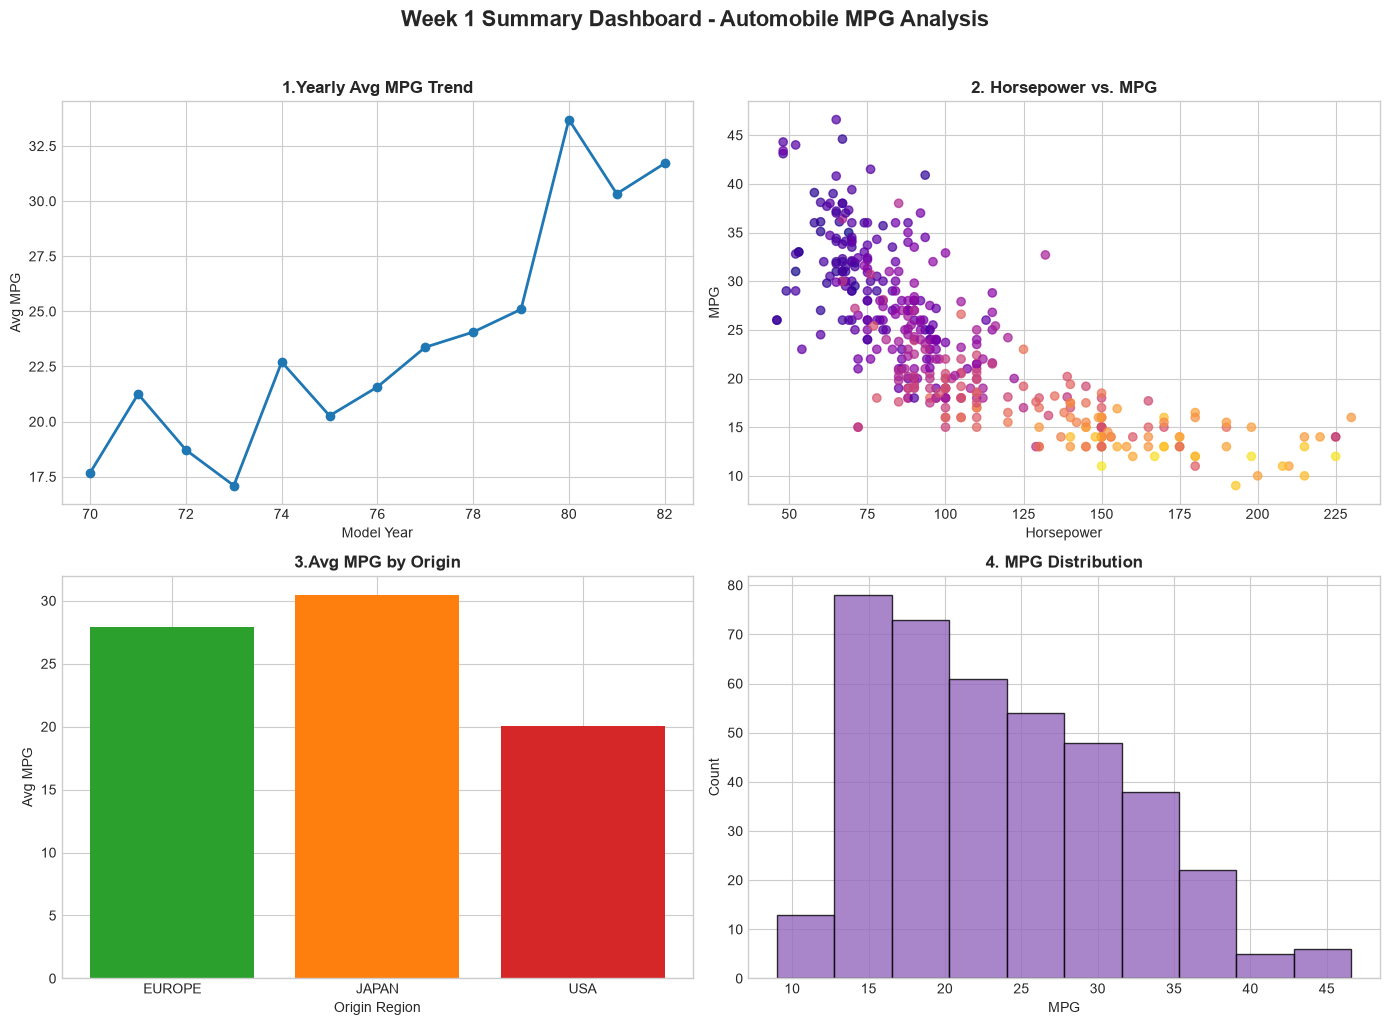

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line Plot
axes[0, 0].plot(yearly_mpg['model_year'], yearly_mpg['mpg'], color='tab:blue', marker='o', linewidth=2)
axes[0, 0].set_title('1.Yearly Avg MPG Trend', fontweight='bold')
axes[0, 0].set_xlabel('Model Year')
axes[0, 0].set_ylabel('Avg MPG')

# 2. Scatter Plot
scatter_plot = axes[0, 1].scatter(df_mpg['horsepower'], df_mpg['mpg'], c=df_mpg['weight'], cmap='plasma', alpha=0.7)
axes[0, 1].set_title('2. Horsepower vs. MPG', fontweight='bold')
axes[0, 1].set_xlabel('Horsepower')
axes[0, 1].set_ylabel('MPG')

# 3. Bar Chart
axes[1, 0].bar(origin_mpg['origin'].str.upper(), origin_mpg['mpg'], color=['tab:green', 'tab:orange', 'tab:red'])
axes[1, 0].set_title('3.Avg MPG by Origin', fontweight='bold')
axes[1, 0].set_xlabel('Origin Region')
axes[1, 0].set_ylabel('Avg MPG')

# 4. Histogram
axes[1, 1].hist(df_mpg['mpg'], bins=10, color='tab:purple', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('4. MPG Distribution', fontweight='bold')
axes[1, 1].set_xlabel('MPG')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Week 1 Summary Dashboard - Automobile MPG Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()